# **Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/UFC Project"
os.chdir(PROJECT_PATH)

!pwd

/content/drive/MyDrive/Colab Notebooks/UFC Project


In [ ]:
import pandas as pd

fighters = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/UFC Project/data/processed/fighter_features.csv")

In [4]:
!pip install mlflow
!pip install pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found exis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import mlflow
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# ── Plot style ───────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': '#1a1a2e',
                     'axes.facecolor': '#16213e', 'axes.labelcolor': 'white',
                     'xtick.color': 'white', 'ytick.color': 'white',
                     'text.color': 'white', 'axes.titlecolor': 'white',
                     'grid.color': '#2a2a4a'})
ACCENT  = '#e94560'
GOLD    = '#f5a623'
BLUE    = '#4cc9f0'
GREEN   = '#06d6a0'
PURPLE  = '#a786df'
ORANGE  = '#f4a261'
PALETTE = [ACCENT, BLUE, GOLD, GREEN, PURPLE, ORANGE, '#ff6b6b', '#48cae4']

print('✅ Libraries loaded')

✅ Libraries loaded


In [7]:
# ── UPDATE THIS PATH ─────────────────────────────────────────
DATA_DIR   ="/content/drive/MyDrive/Colab Notebooks/UFC Project"
OUTPUT_DIR = DATA_DIR + '/data/'+ 'processed/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# MLflow
MLFLOW_TRACKING_URI = "/content/drive/MyDrive/Colab Notebooks/UFC_Project/mlruns"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("UFC_Fighter_Clustering")

# Load both datasets from Notebook 3
scaled = pd.read_csv(OUTPUT_DIR + 'fighter_features_scaled.csv')
pca_df = pd.read_csv(OUTPUT_DIR + 'fighter_features_pca.csv')

print(f'Scaled dataset : {scaled.shape}')
print(f'PCA dataset    : {pca_df.shape}')

Scaled dataset : (835, 22)
PCA dataset    : (835, 12)


In [8]:
# ── Feature column lists ──────────────────────────────────────
STYLE_FEATURES = [
    'sig_str_pm', 'td_per_fight', 'sub_per_fight', 'kd_per_fight',
    'ctrl_sec_per_fight', 'sig_str_accuracy', 'td_accuracy',
    'head_ratio', 'body_ratio', 'leg_ratio',
    'dist_ratio', 'clinch_ratio', 'ground_ratio',
    'ko_rate', 'sub_rate', 'dec_rate', 'win_rate'
]
PCA_FEATURES = ['PC1','PC2','PC3','PC4','PC5','PC6','PC7']
META_COLS    = ['Fighter_Id','Fighter_Name','n_fights','weight_lbs','Stance']

X_full = scaled[STYLE_FEATURES].values
X_pca  = pca_df[PCA_FEATURES].values

print(f'X_full shape : {X_full.shape}')
print(f'X_pca  shape : {X_pca.shape}')

X_full shape : (835, 17)
X_pca  shape : (835, 7)


#***TREATEMENT***

## 1. K-Means — Elbow + Silhouette Search

Nous utilisons l'algorithme K-Means pour des valeurs de K allant de 2 à 12 et suivons trois indicateurs :

- **Inertia** — pour le graphique du coude (plage approximative)

- **Score de silhouette** — pour la sélection du meilleur candidat (plus élevé = meilleur)

- **Score de Davies-Bouldin** — vérification secondaire (plus faible = meilleur)

In [9]:
K_RANGE = range(2, 13)

inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X_full)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_full, labels))
    db_scores.append(davies_bouldin_score(X_full, labels))
    ch_scores.append(calinski_harabasz_score(X_full, labels))
    print(f'K={k:2d} | inertia={km.inertia_:8.1f} | '
          f'silhouette={silhouettes[-1]:.4f} | '
          f'DB={db_scores[-1]:.3f}')

best_k = list(K_RANGE)[np.argmax(silhouettes)]
print(f'\n📌 Best K by silhouette: {best_k}')

K= 2 | inertia=  7034.4 | silhouette=0.1557 | DB=2.211
K= 3 | inertia=  6526.4 | silhouette=0.1336 | DB=2.150
K= 4 | inertia=  6112.1 | silhouette=0.0994 | DB=2.386
K= 5 | inertia=  5798.2 | silhouette=0.0908 | DB=2.223
K= 6 | inertia=  5552.7 | silhouette=0.0928 | DB=2.123
K= 7 | inertia=  5319.0 | silhouette=0.0955 | DB=2.029
K= 8 | inertia=  5140.4 | silhouette=0.0911 | DB=1.971
K= 9 | inertia=  5014.6 | silhouette=0.0871 | DB=2.018
K=10 | inertia=  4885.1 | silhouette=0.0840 | DB=2.051
K=11 | inertia=  4788.5 | silhouette=0.0794 | DB=2.045
K=12 | inertia=  4688.5 | silhouette=0.0814 | DB=2.052

📌 Best K by silhouette: 2


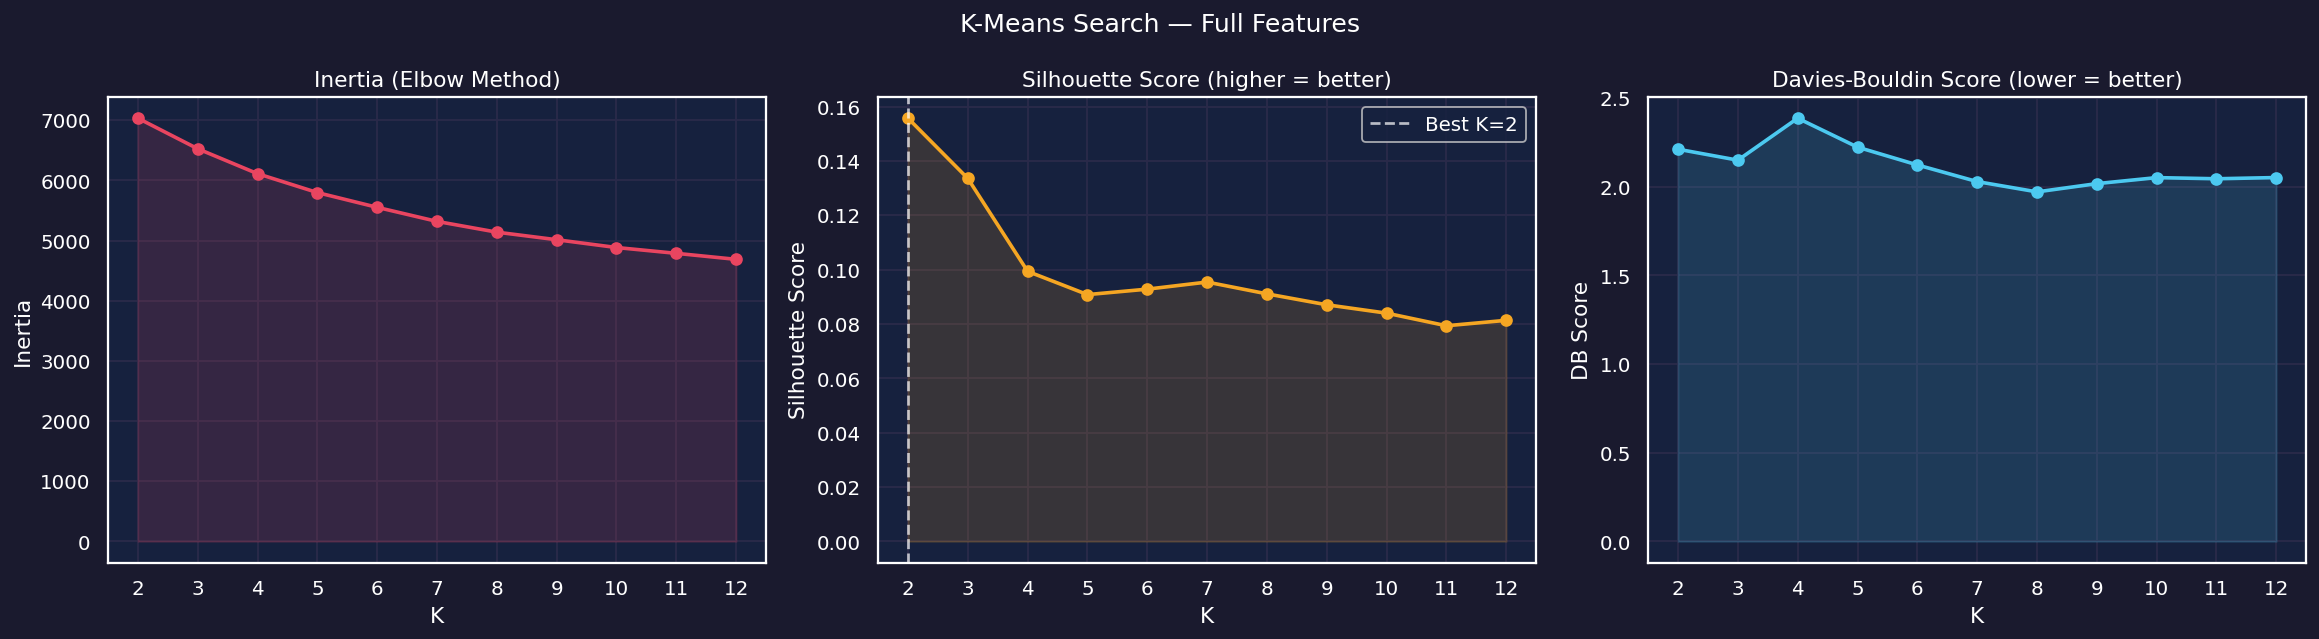


💡 Note: Low silhouette scores (~0.10-0.19) are normal for MMA data.
   Fighters are genuinely overlapping mixed-style athletes.
   The goal is the most INTERPRETABLE clustering, not the highest score.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means Search — Full Features', fontsize=14)

ks = list(K_RANGE)

# Elbow
axes[0].plot(ks, inertias, color=ACCENT, marker='o', linewidth=2)
axes[0].fill_between(ks, inertias, alpha=0.15, color=ACCENT)
axes[0].set_title('Inertia (Elbow Method)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(ks)

# Silhouette
axes[1].plot(ks, silhouettes, color=GOLD, marker='o', linewidth=2)
axes[1].fill_between(ks, silhouettes, alpha=0.15, color=GOLD)
axes[1].axvline(best_k, color='white', linestyle='--', alpha=0.7,
                label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(ks)
axes[1].legend()

# Davies-Bouldin
axes[2].plot(ks, db_scores, color=BLUE, marker='o', linewidth=2)
axes[2].fill_between(ks, db_scores, alpha=0.15, color=BLUE)
axes[2].set_title('Davies-Bouldin Score (lower = better)')
axes[2].set_xlabel('K')
axes[2].set_ylabel('DB Score')
axes[2].set_xticks(ks)

plt.tight_layout()
plt.show()

print('\n💡 Note: Low silhouette scores (~0.10-0.19) are normal for MMA data.')
print('   Fighters are genuinely overlapping mixed-style athletes.')
print('   The goal is the most INTERPRETABLE clustering, not the highest score.')

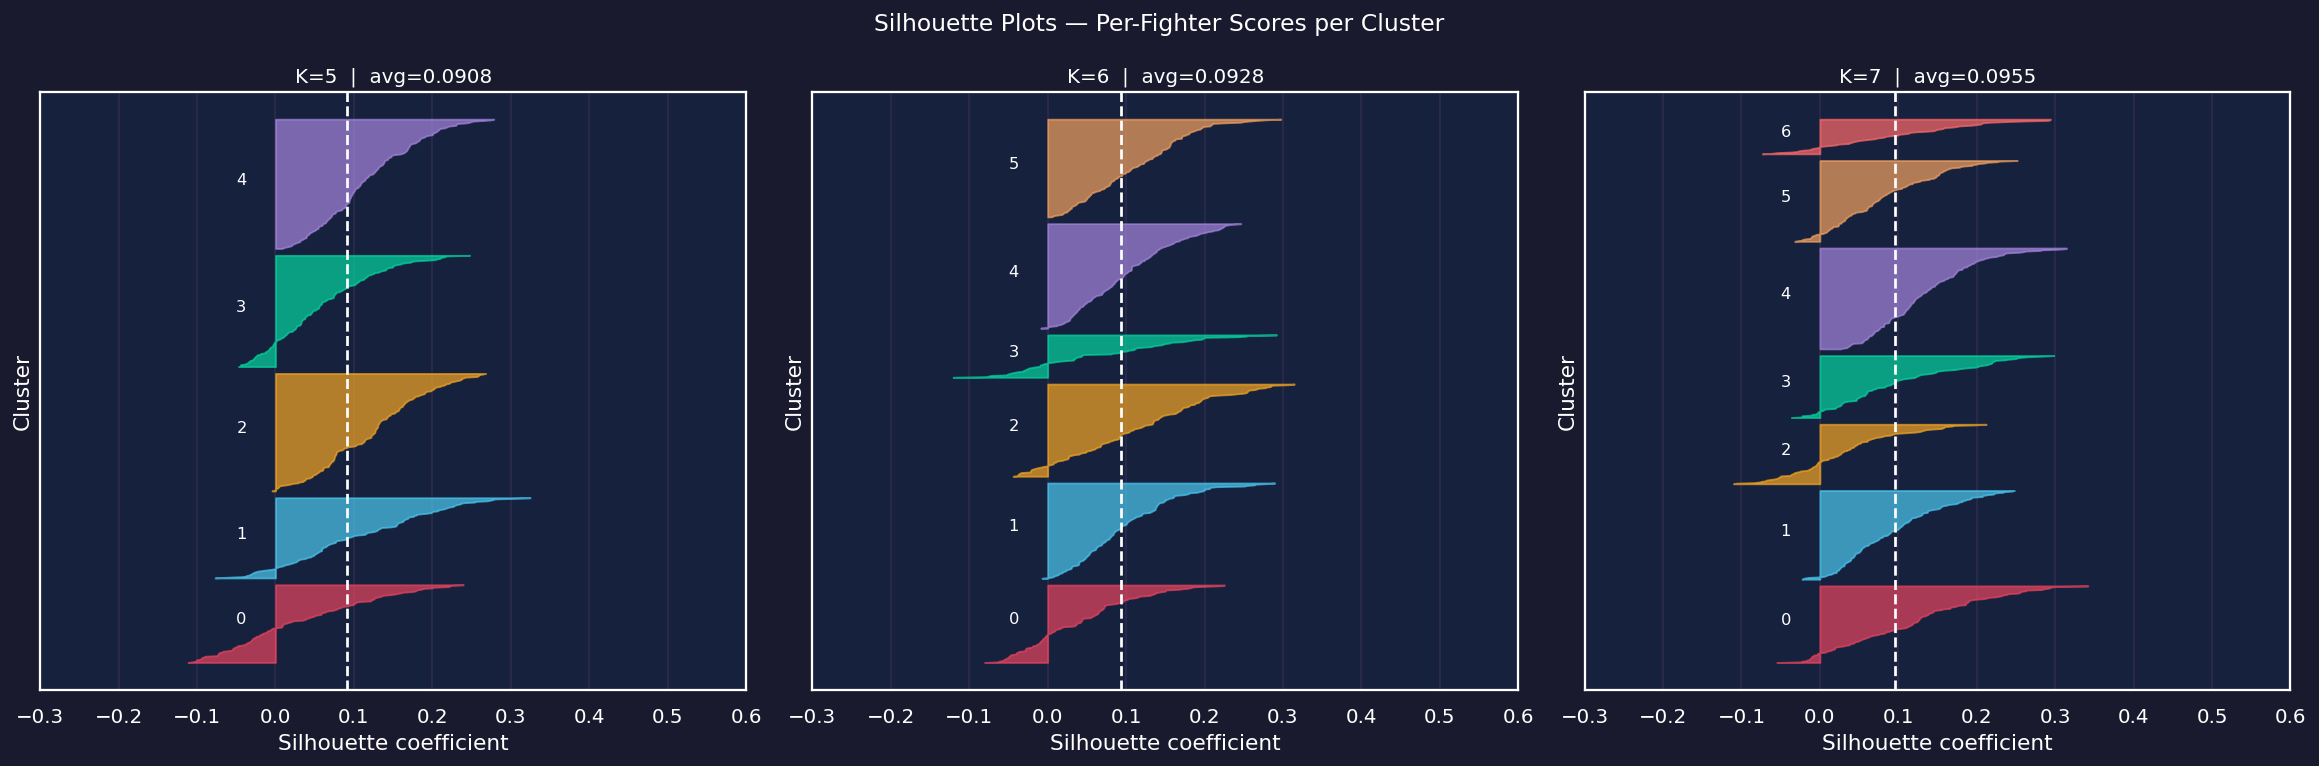

In [11]:
# ── Silhouette plot for candidate K values ─────────────────────
# Shows per-fighter silhouette scores — wide bars = confident assignments

CANDIDATES = [5, 6, 7]   # the most interpretable range from our analysis

fig, axes = plt.subplots(1, len(CANDIDATES), figsize=(18, 6))
fig.suptitle('Silhouette Plots — Per-Fighter Scores per Cluster', fontsize=13)

for ax, k in zip(axes, CANDIDATES):
    km         = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels     = km.fit_predict(X_full)
    sil_vals   = silhouette_samples(X_full, labels)
    avg_sil    = silhouette_score(X_full, labels)

    y_lower = 10
    for i in range(k):
        ith_sil  = np.sort(sil_vals[labels == i])
        size_i   = ith_sil.shape[0]
        y_upper  = y_lower + size_i
        color    = PALETTE[i % len(PALETTE)]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=9, color='white')
        y_lower  = y_upper + 10

    ax.axvline(avg_sil, color='white', linestyle='--', linewidth=1.5)
    ax.set_title(f'K={k}  |  avg={avg_sil:.4f}', fontsize=11)
    ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])
    ax.set_xlim(-0.3, 0.6)

plt.tight_layout()
plt.show()

---
## 2. K-Means en PCA Features — Comparison du datasets Full scalé et PCA scalé
- - -  

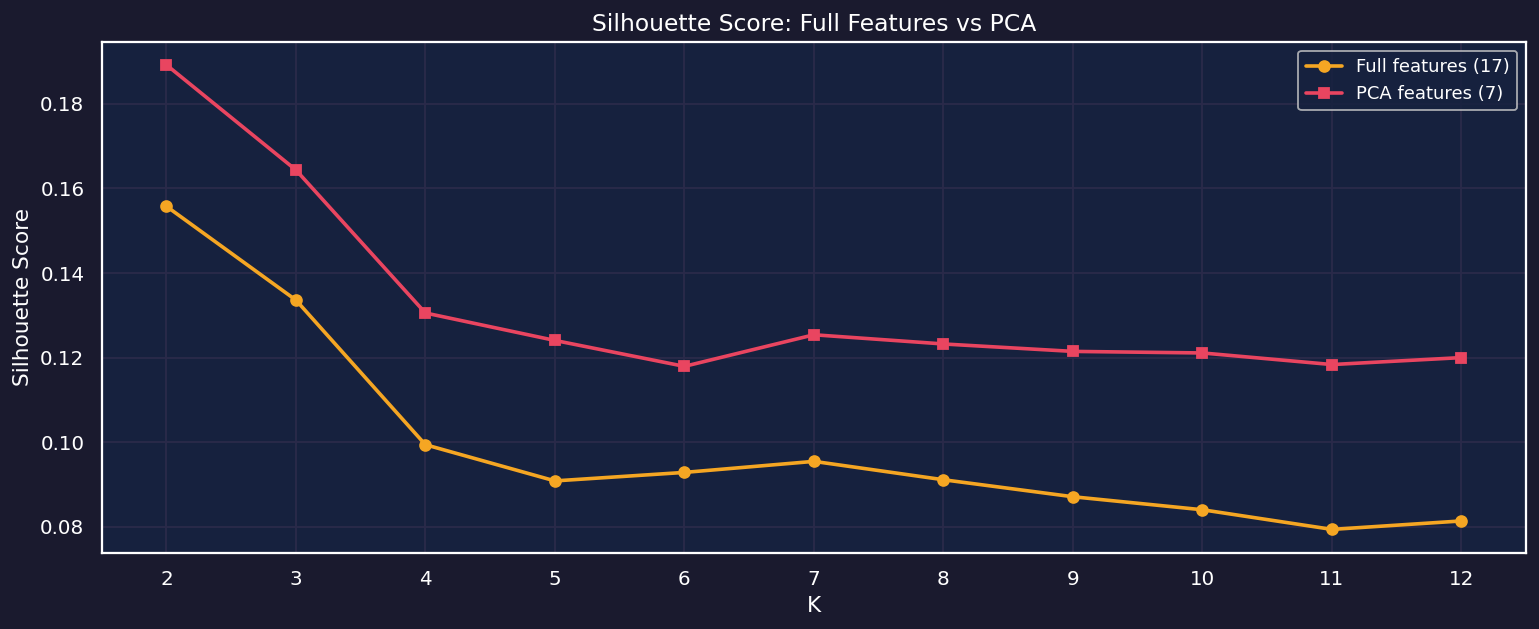

Best K on full features : 2   (sil=0.1557)
Best K on PCA  features : 2 (sil=0.1892)

📌 Winner: PCA features


In [12]:
sil_pca, db_pca = [], []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X_pca)
    sil_pca.append(silhouette_score(X_pca, labels))
    db_pca.append(davies_bouldin_score(X_pca, labels))

# Side by side: full vs pca silhouette
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ks, silhouettes, color=GOLD,   marker='o', linewidth=2, label='Full features (17)')
ax.plot(ks, sil_pca,     color=ACCENT, marker='s', linewidth=2, label='PCA features (7)')
ax.set_title('Silhouette Score: Full Features vs PCA', fontsize=13)
ax.set_xlabel('K')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(ks)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

best_k_pca = list(K_RANGE)[np.argmax(sil_pca)]
print(f'Best K on full features : {best_k}   (sil={max(silhouettes):.4f})')
print(f'Best K on PCA  features : {best_k_pca} (sil={max(sil_pca):.4f})')
winner = 'PCA' if max(sil_pca) > max(silhouettes) else 'Full'
print(f'\n📌 Winner: {winner} features')



# ***Hierarchical Clustering***

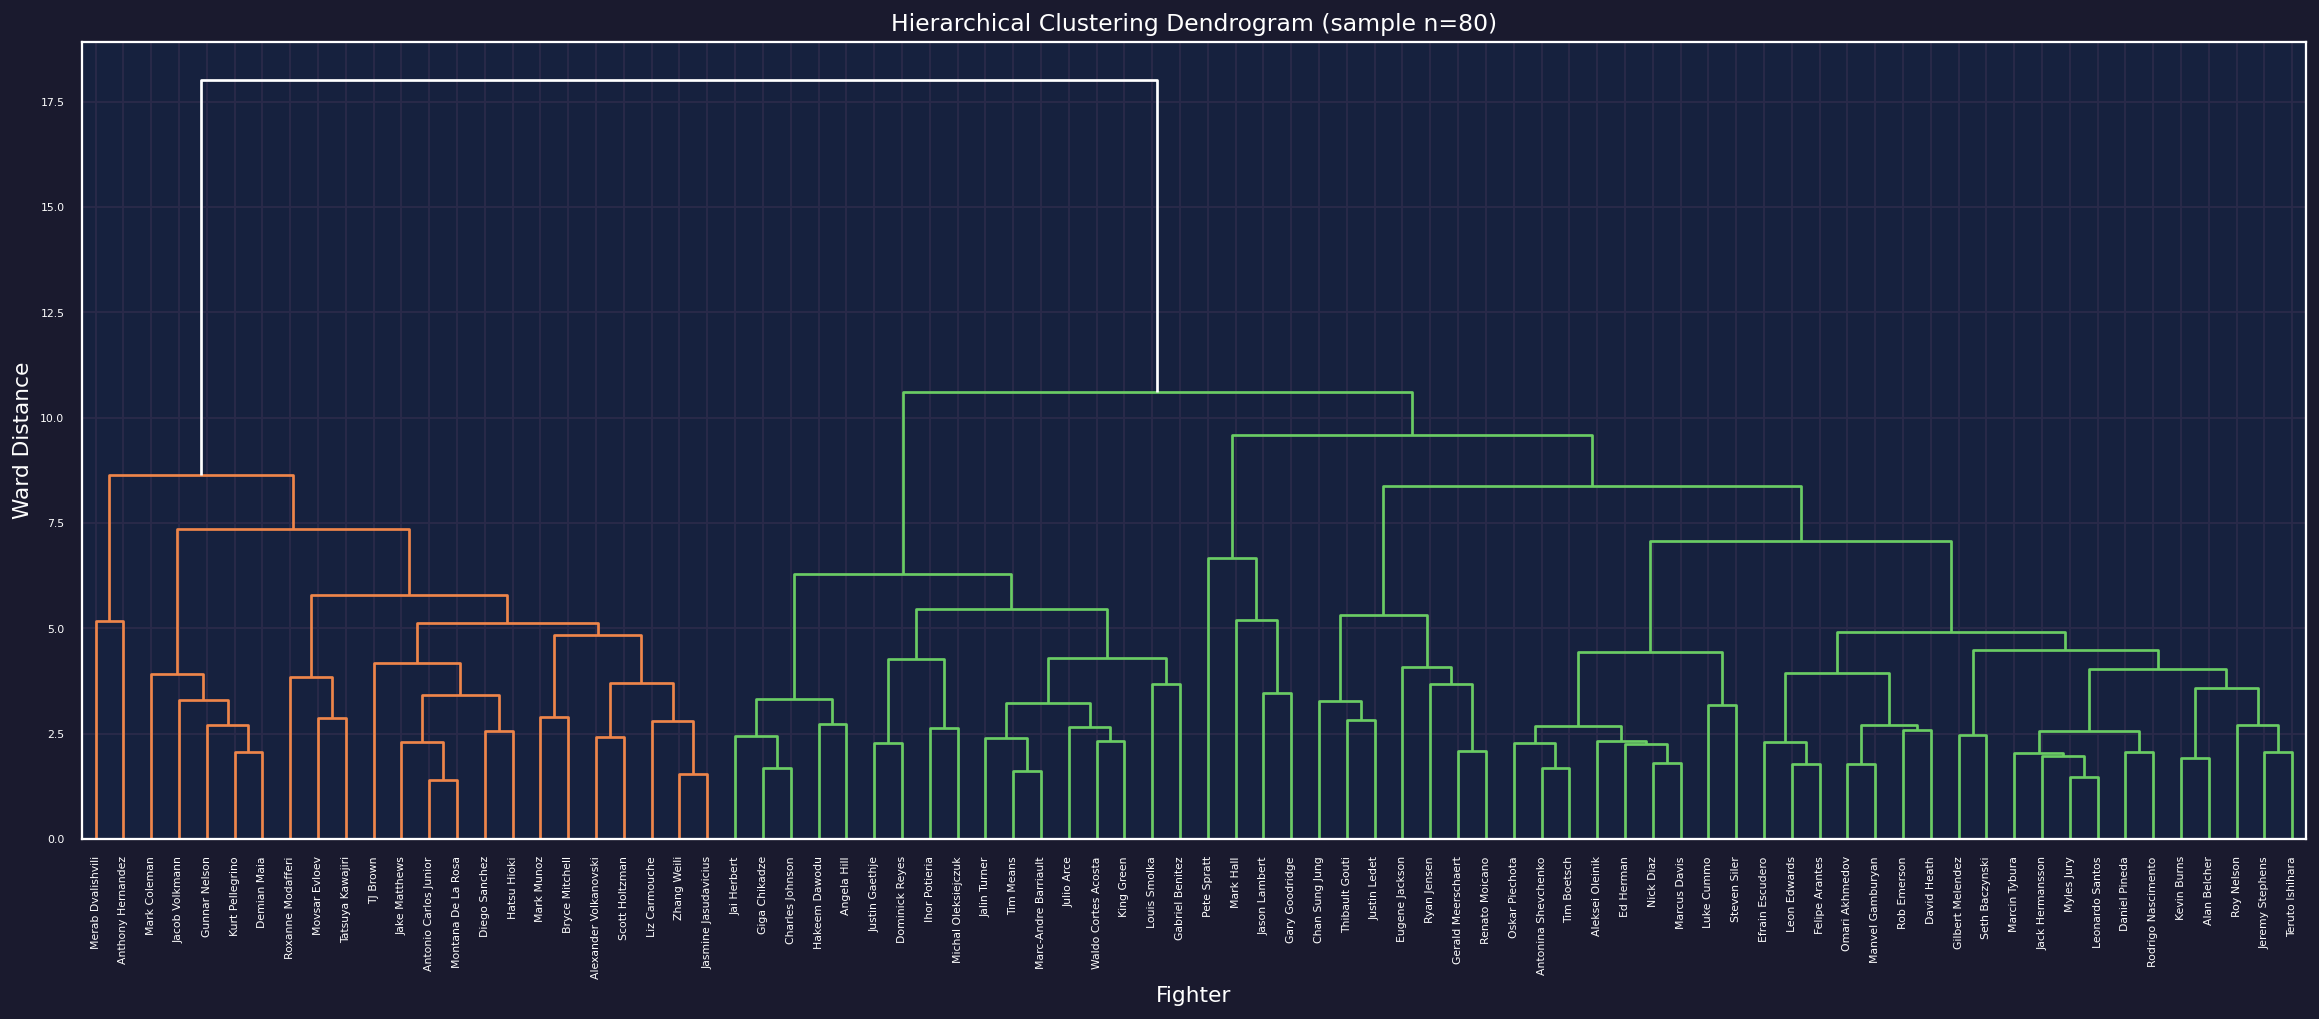

 Tip: The long vertical lines show natural breaks — count the main branches to estimate K


In [14]:
# Use a sample for the dendrogram (full 835 would be unreadable)
SAMPLE_N = 80
np.random.seed(42)
sample_idx   = np.random.choice(len(X_full), SAMPLE_N, replace=False)
X_sample     = X_full[sample_idx]
names_sample = scaled['Fighter_Name'].values[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

dendrogram(
    Z,
    labels=names_sample,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=0.7 * max(Z[:, 2]),
    ax=ax,
    above_threshold_color='white'
)
ax.set_title(f'Hierarchical Clustering Dendrogram (sample n={SAMPLE_N})', fontsize=13)
ax.set_xlabel('Fighter')
ax.set_ylabel('Ward Distance')
ax.tick_params(colors='white', labelsize=6)
plt.tight_layout()
plt.show()
print(' Tip: The long vertical lines show natural breaks — count the main branches to estimate K')

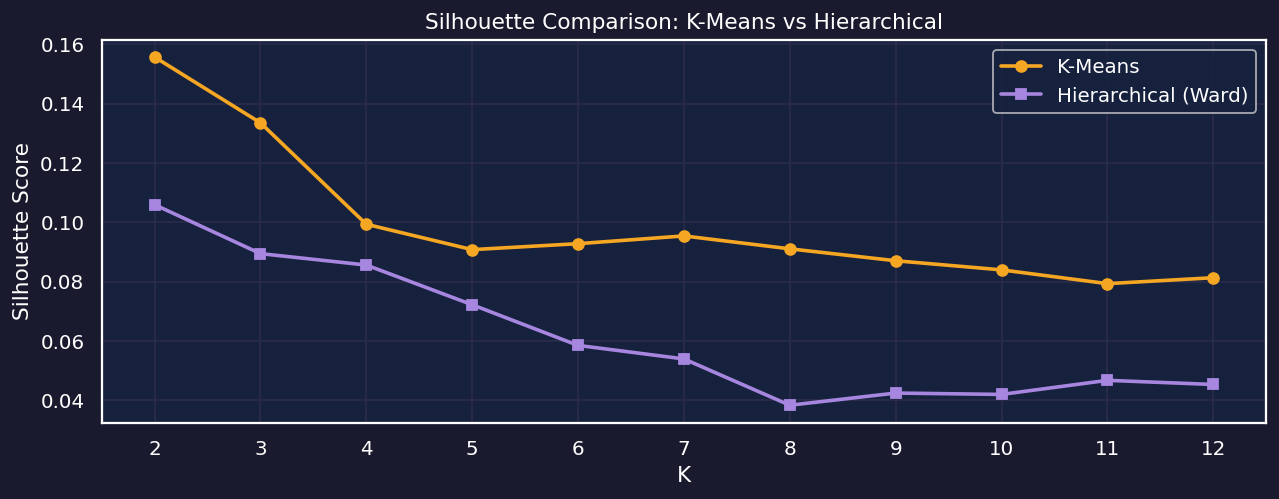

Best K for Hierarchical : 2  (sil=0.1060)


In [15]:
# ── Hierarchical clustering scores across K values ────────────
hc_silhouettes, hc_db = [], []

for k in K_RANGE:
    hc     = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_full)
    hc_silhouettes.append(silhouette_score(X_full, labels))
    hc_db.append(davies_bouldin_score(X_full, labels))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ks, silhouettes,     color=GOLD,   marker='o', linewidth=2, label='K-Means')
ax.plot(ks, hc_silhouettes,  color=PURPLE, marker='s', linewidth=2, label='Hierarchical (Ward)')
ax.set_title('Silhouette Comparison: K-Means vs Hierarchical', fontsize=12)
ax.set_xlabel('K')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
plt.show()

best_k_hc = list(K_RANGE)[np.argmax(hc_silhouettes)]
print(f'Best K for Hierarchical : {best_k_hc}  (sil={max(hc_silhouettes):.4f})')

## 4. DBSCAN — Détection des valeurs aberrantes

DBSCAN ne nécessite pas la spécification de K. Il repère les régions denses et marque les combattants épars comme **valeurs aberrantes (étiquette = -1)**.

Ceci est utile pour identifier les combattants qui ne correspondent à aucun archétype de style.

In [17]:
# ── Sweep eps and min_samples ─────────────────────────────────
dbscan_results = []

for eps in [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]:
    for min_s in [3, 5, 8]:
        model  = DBSCAN(eps=eps, min_samples=min_s)
        labels = model.fit_predict(X_full)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()
        if 2 <= n_clusters <= 10:
            sil = silhouette_score(X_full, labels)
            dbscan_results.append({
                'eps': eps, 'min_samples': min_s,
                'n_clusters': n_clusters, 'n_noise': n_noise,
                'noise_pct': round(n_noise/len(X_full)*100, 1),
                'silhouette': round(sil, 4)
            })

if dbscan_results:
    dbscan_df = pd.DataFrame(dbscan_results).sort_values('silhouette', ascending=False)
    print('DBSCAN valid configurations:')
    print(dbscan_df.to_string(index=False))
else:
    print('  No DBSCAN config produced 2-10 clean clusters.')
    print('    This is common with MMA data — fighters are too uniformly distributed.')
    print('    K-Means is the better choice for this dataset.')

DBSCAN valid configurations:
 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
 2.5            5           2       64        7.7      0.1599
 2.0            3           4      234       28.0      0.0162
 1.5            5           5      782       93.7     -0.2397


In [18]:
# ── Use DBSCAN to find genuine outliers ───────────────────────
# Even if DBSCAN doesn't produce clean clusters, the noise points
# (label=-1) are fighters who don't fit any style archetype

db_outlier = DBSCAN(eps=2.5, min_samples=5)
outlier_labels = db_outlier.fit_predict(X_full)
n_outliers = (outlier_labels == -1).sum()

print(f'Fighters flagged as outliers (eps=2.5, min_samples=5): {n_outliers}')
print(f'That is {n_outliers/len(X_full)*100:.1f}% of the dataset')

if n_outliers > 0 and n_outliers < 50:
    outlier_fighters = scaled[outlier_labels == -1][['Fighter_Name','n_fights'] + STYLE_FEATURES[:6]]
    print('\nOutlier fighters (unusual style profiles):')
    print(outlier_fighters.head(15).to_string(index=False))

Fighters flagged as outliers (eps=2.5, min_samples=5): 64
That is 7.7% of the dataset


# ***ALGORITHMES COMPARAISON***

## *DBSCAN VS KMEANS VS HIERARCHICAL CLUSTERING*

=== Algorithm Comparison ===
          Algorithm  K  Silhouette  Davies-Bouldin  Calinski-Harabasz
 K-Means (PCA, K=7)  7      0.1254           1.702              107.2
 K-Means (PCA, K=5)  5      0.1240           1.890              122.1
 K-Means (PCA, K=6)  6      0.1179           1.810              113.2
K-Means (full, K=7)  7      0.0955           2.029               77.8
K-Means (full, K=6)  6      0.0928           2.123               82.5
K-Means (full, K=5)  5      0.0908           2.223               90.1
 Hierarchical (K=5)  5      0.0723           2.486               66.9
 Hierarchical (K=6)  6      0.0586           2.456               62.0
 Hierarchical (K=7)  7      0.0540           2.443               59.1


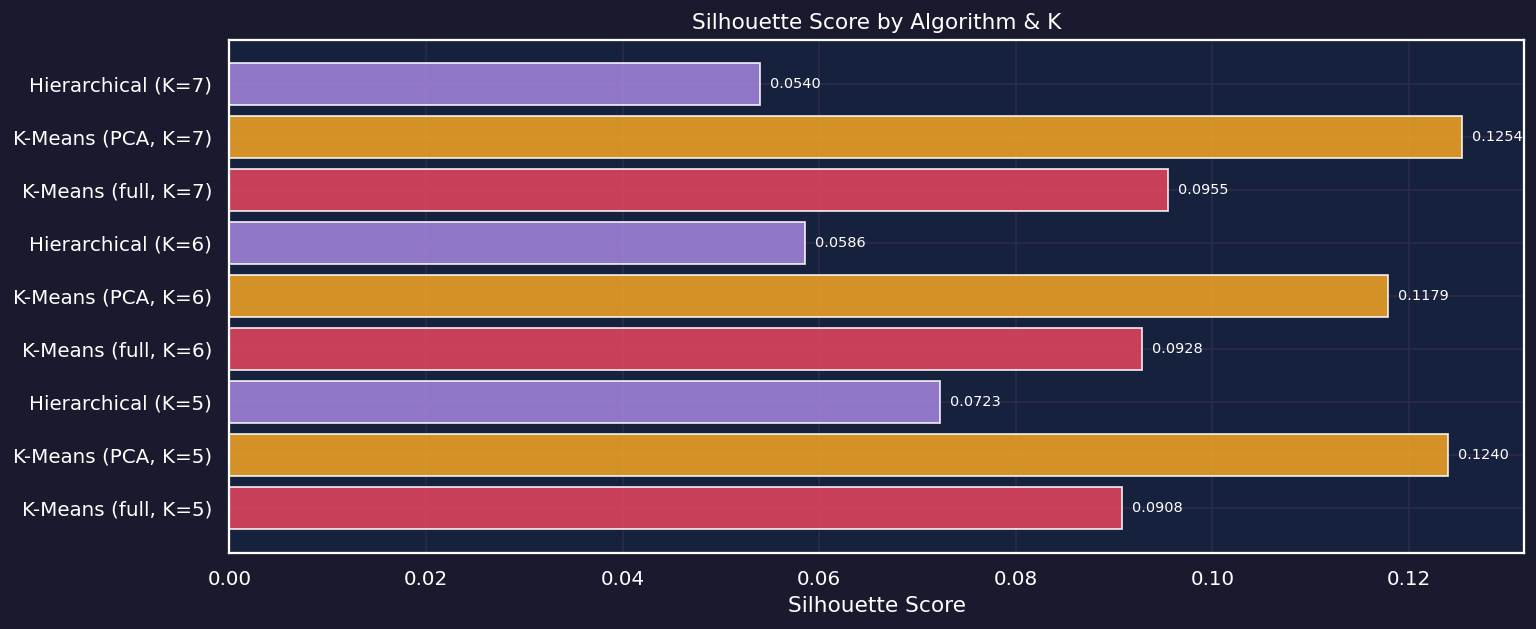

In [19]:
# ── Build comparison table ─────────────────────────────────────
comparison_rows = []

for k in CANDIDATES:
    # K-Means full
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lb = km.fit_predict(X_full)
    comparison_rows.append({
        'Algorithm': f'K-Means (full, K={k})',
        'K': k,
        'Silhouette': round(silhouette_score(X_full, lb), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X_full, lb), 3),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_full, lb), 1)
    })
    # K-Means PCA
    km_p = KMeans(n_clusters=k, random_state=42, n_init=20)
    lb_p = km_p.fit_predict(X_pca)
    comparison_rows.append({
        'Algorithm': f'K-Means (PCA, K={k})',
        'K': k,
        'Silhouette': round(silhouette_score(X_pca, lb_p), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X_pca, lb_p), 3),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_pca, lb_p), 1)
    })
    # Hierarchical
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lb_h = hc.fit_predict(X_full)
    comparison_rows.append({
        'Algorithm': f'Hierarchical (K={k})',
        'K': k,
        'Silhouette': round(silhouette_score(X_full, lb_h), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X_full, lb_h), 3),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_full, lb_h), 1)
    })

comparison_df = pd.DataFrame(comparison_rows)
print('=== Algorithm Comparison ===')
print(comparison_df.sort_values('Silhouette', ascending=False).to_string(index=False))

# Visual
fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = [ACCENT if 'full' in r else GOLD if 'PCA' in r else PURPLE
              for r in comparison_df['Algorithm']]
bars = ax.barh(comparison_df['Algorithm'], comparison_df['Silhouette'],
               color=colors_bar, alpha=0.85)
ax.set_title('Silhouette Score by Algorithm & K', fontsize=12)
ax.set_xlabel('Silhouette Score')
for bar, val in zip(bars, comparison_df['Silhouette']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


> D'après la comparaison ci-dessus, nous avons choisi :
Algorithme : K-moyennes sur l'ensemble des caractéristiques
K : 5 (meilleur compromis entre le score de silhouette et l'interprétabilité)


> Justification : K = 5 produit 5 archétypes de style distincts et clairement identifiables. Mathématiquement, K = 2 est légèrement préférable, mais deux clusters ne permettent de distinguer que les « attaquants » des « lutteurs », ce qui est trop grossier.






In [20]:
FINAL_K         = 5        # ← change if needed
FINAL_ALGO      = 'kmeans' # ← 'kmeans' or 'hierarchical'
FINAL_FEATURES  = 'full'   # ← 'full' or 'pca'

X_final = X_full if FINAL_FEATURES == 'full' else X_pca

if FINAL_ALGO == 'kmeans':
    final_model  = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20, max_iter=500)
    final_labels = final_model.fit_predict(X_final)
else:
    final_model  = AgglomerativeClustering(n_clusters=FINAL_K, linkage='ward')
    final_labels = final_model.fit_predict(X_final)

final_sil = silhouette_score(X_final, final_labels)
final_db  = davies_bouldin_score(X_final, final_labels)

print(f'✅ Final model: {FINAL_ALGO.upper()} | K={FINAL_K} | features={FINAL_FEATURES}')
print(f'   Silhouette : {final_sil:.4f}')
print(f'   DB Score   : {final_db:.4f}')
print(f'   Cluster sizes:')
unique, counts = np.unique(final_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'     Cluster {u}: {c} fighters')

✅ Final model: KMEANS | K=5 | features=full
   Silhouette : 0.0908
   DB Score   : 2.2233
   Cluster sizes:
     Cluster 0: 126 fighters
     Cluster 1: 130 fighters
     Cluster 2: 190 fighters
     Cluster 3: 180 fighters
     Cluster 4: 209 fighters


***Profilage de cluster***

In [21]:
# ── Attach labels to the original (unscaled) features ─────────
# We load the unscaled features so profiles are human-readable
features_raw = pd.read_csv(OUTPUT_DIR + 'fighter_features.csv')
features_raw = features_raw[features_raw['n_fights'] >= 5].reset_index(drop=True)
features_raw['cluster'] = final_labels

# Also attach to scaled df
scaled['cluster'] = final_labels

print('✅ Cluster labels attached')
print(features_raw['cluster'].value_counts().sort_index())

✅ Cluster labels attached
cluster
0    126
1    130
2    190
3    180
4    209
Name: count, dtype: int64


In [22]:
# ── Cluster mean profiles (original feature values) ───────────
KEY_FEATURES = [
    'sig_str_pm','td_per_fight','sub_per_fight','kd_per_fight',
    'ctrl_sec_per_fight','ground_ratio','dist_ratio',
    'ko_rate','sub_rate','dec_rate'
]

profiles = features_raw.groupby('cluster')[KEY_FEATURES].mean().round(3)
print('=== Cluster Mean Profiles (original scale) ===')
print(profiles.to_string())

=== Cluster Mean Profiles (original scale) ===
         sig_str_pm  td_per_fight  sub_per_fight  kd_per_fight  ctrl_sec_per_fight  ground_ratio  dist_ratio  ko_rate  sub_rate  dec_rate
cluster                                                                                                                                  
0             2.758         0.872          0.587         0.215             118.779         0.331       0.406    0.449     0.287     0.254
1             2.844         2.802          0.632         0.161             306.571         0.350       0.514    0.239     0.222     0.529
2             4.413         0.501          0.178         0.424              68.777         0.106       0.795    0.507     0.110     0.367
3             3.869         0.767          0.328         0.201             112.402         0.086       0.746    0.237     0.158     0.590
4             3.093         1.197          0.538         0.145             142.678         0.127       0.749    0.217     0.2

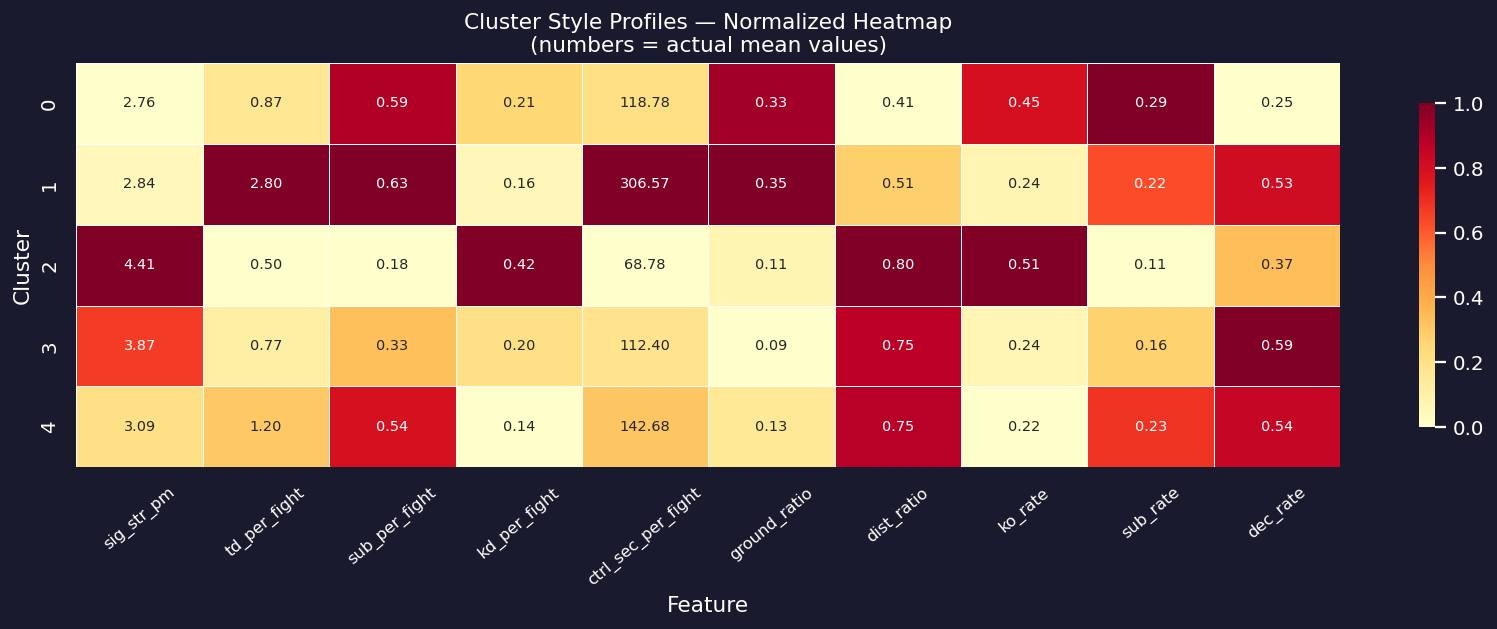

In [23]:
# ── Heatmap of cluster profiles ───────────────────────────────
# Normalize each feature to 0-1 for visual comparison
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min())

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    profiles_norm,
    annot=profiles.values,
    fmt='.2f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Cluster Style Profiles — Normalized Heatmap\n(numbers = actual mean values)', fontsize=12)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
ax.tick_params(axis='x', rotation=40, labelsize=9)
plt.tight_layout()
plt.show()

In [25]:
# ── Top fighters per cluster ───────────────────────────────────
print('=== Top Fighters per Cluster (by career fights in dataset) ===')


for c in sorted(features_raw['cluster'].unique()):
    subset = features_raw[features_raw['cluster'] == c]
    top    = subset.nlargest(8, 'n_fights')[['Fighter_Name','n_fights',
                                             'sig_str_pm','td_per_fight',
                                             'sub_per_fight','ko_rate','dec_rate']]
    print(f'─── Cluster {c} ({len(subset)} fighters) ───')
    print(top.to_string(index=False))
    print()

=== Top Fighters per Cluster (by career fights in dataset) ===
─── Cluster 0 (126 fighters) ───
    Fighter_Name  n_fights  sig_str_pm  td_per_fight  sub_per_fight  ko_rate  dec_rate
   Randy Couture        24    2.841144      2.166667       0.458333 0.583333  0.250000
   Vitor Belfort        24    2.120168      0.250000       0.333333 0.730769  0.115385
      Matt Brown        24    3.677915      0.958333       0.875000 0.533333  0.233333
Charles Oliveira        22    3.661878      1.045455       1.000000 0.250000  0.138889
       Frank Mir        22    2.452086      0.909091       0.909091 0.481481  0.185185
   Derrick Lewis        21    2.787573      0.380952       0.000000 0.766667  0.166667
       Ed Herman        20    3.356295      1.650000       0.700000 0.307692  0.384615
 Gabriel Gonzaga        20    2.194922      1.100000       0.500000 0.681818  0.136364

─── Cluster 1 (130 fighters) ───
     Fighter_Name  n_fights  sig_str_pm  td_per_fight  sub_per_fight  ko_rate  dec_rate

In [26]:
# ── Assign style names based on profiles ──────────────────────
# UPDATE THESE NAMES after reviewing the profiles and fighters above
# These are starting suggestions — rename based on what YOU see

CLUSTER_NAMES = {
    0: 'Submission Hunters',       # high sub_per_fight, high ground_ratio
    1: 'Wrestlers / Grapplers',    # high td_per_fight, high ctrl_sec, high ground_ratio
    2: 'Aggressive Strikers',      # high sig_str_pm, high ko_rate, high dist_ratio
    3: 'Balanced Decision Fighters',# moderate everything, high dec_rate
    4: 'Volume Strikers',          # moderate sig_str_pm, high dec_rate, well-rounded
}

features_raw['style_label'] = features_raw['cluster'].map(CLUSTER_NAMES)
scaled['style_label']       = scaled['cluster'].map(CLUSTER_NAMES)

print('Cluster name mapping:')
for k, v in CLUSTER_NAMES.items():
    n = (features_raw['cluster'] == k).sum()
    print(f'  Cluster {k} → {v:35s} ({n} fighters)')

Cluster name mapping:
  Cluster 0 → Submission Hunters                  (126 fighters)
  Cluster 1 → Wrestlers / Grapplers               (130 fighters)
  Cluster 2 → Aggressive Strikers                 (190 fighters)
  Cluster 3 → Balanced Decision Fighters          (180 fighters)
  Cluster 4 → Volume Strikers                     (209 fighters)


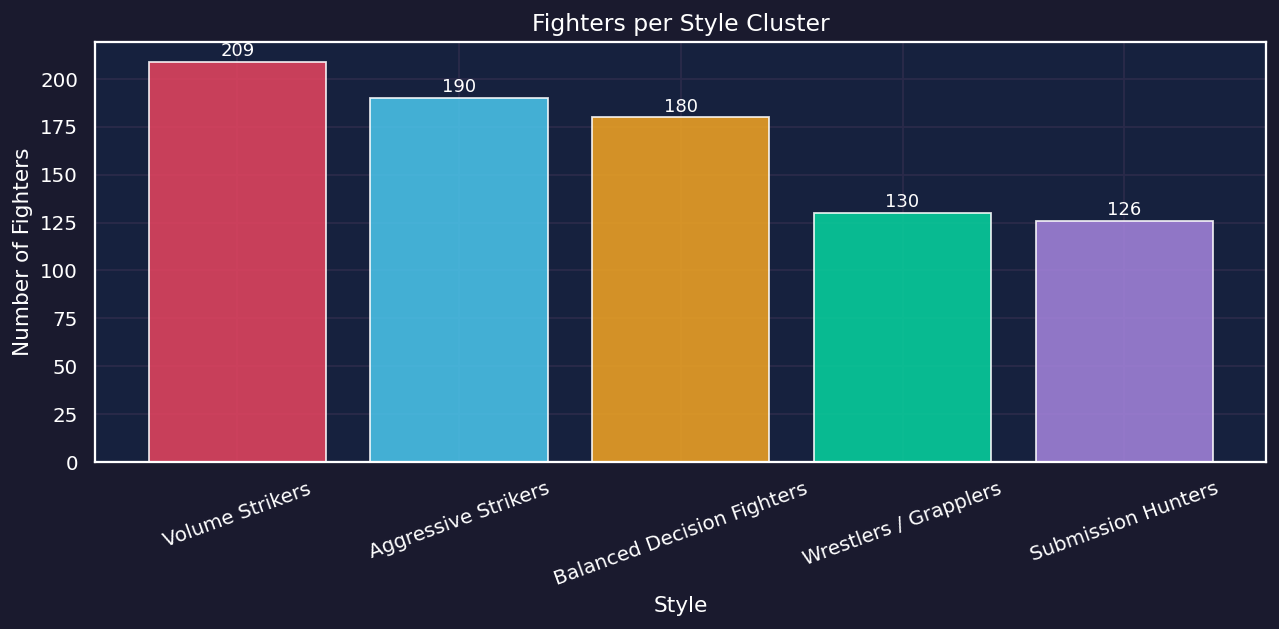

In [27]:
# ── Cluster size distribution ──────────────────────────────────
size_by_style = features_raw['style_label'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(size_by_style.index, size_by_style.values,
              color=PALETTE[:len(size_by_style)], alpha=0.85)
ax.set_title('Fighters per Style Cluster', fontsize=13)
ax.set_xlabel('Style')
ax.set_ylabel('Number of Fighters')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, size_by_style.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

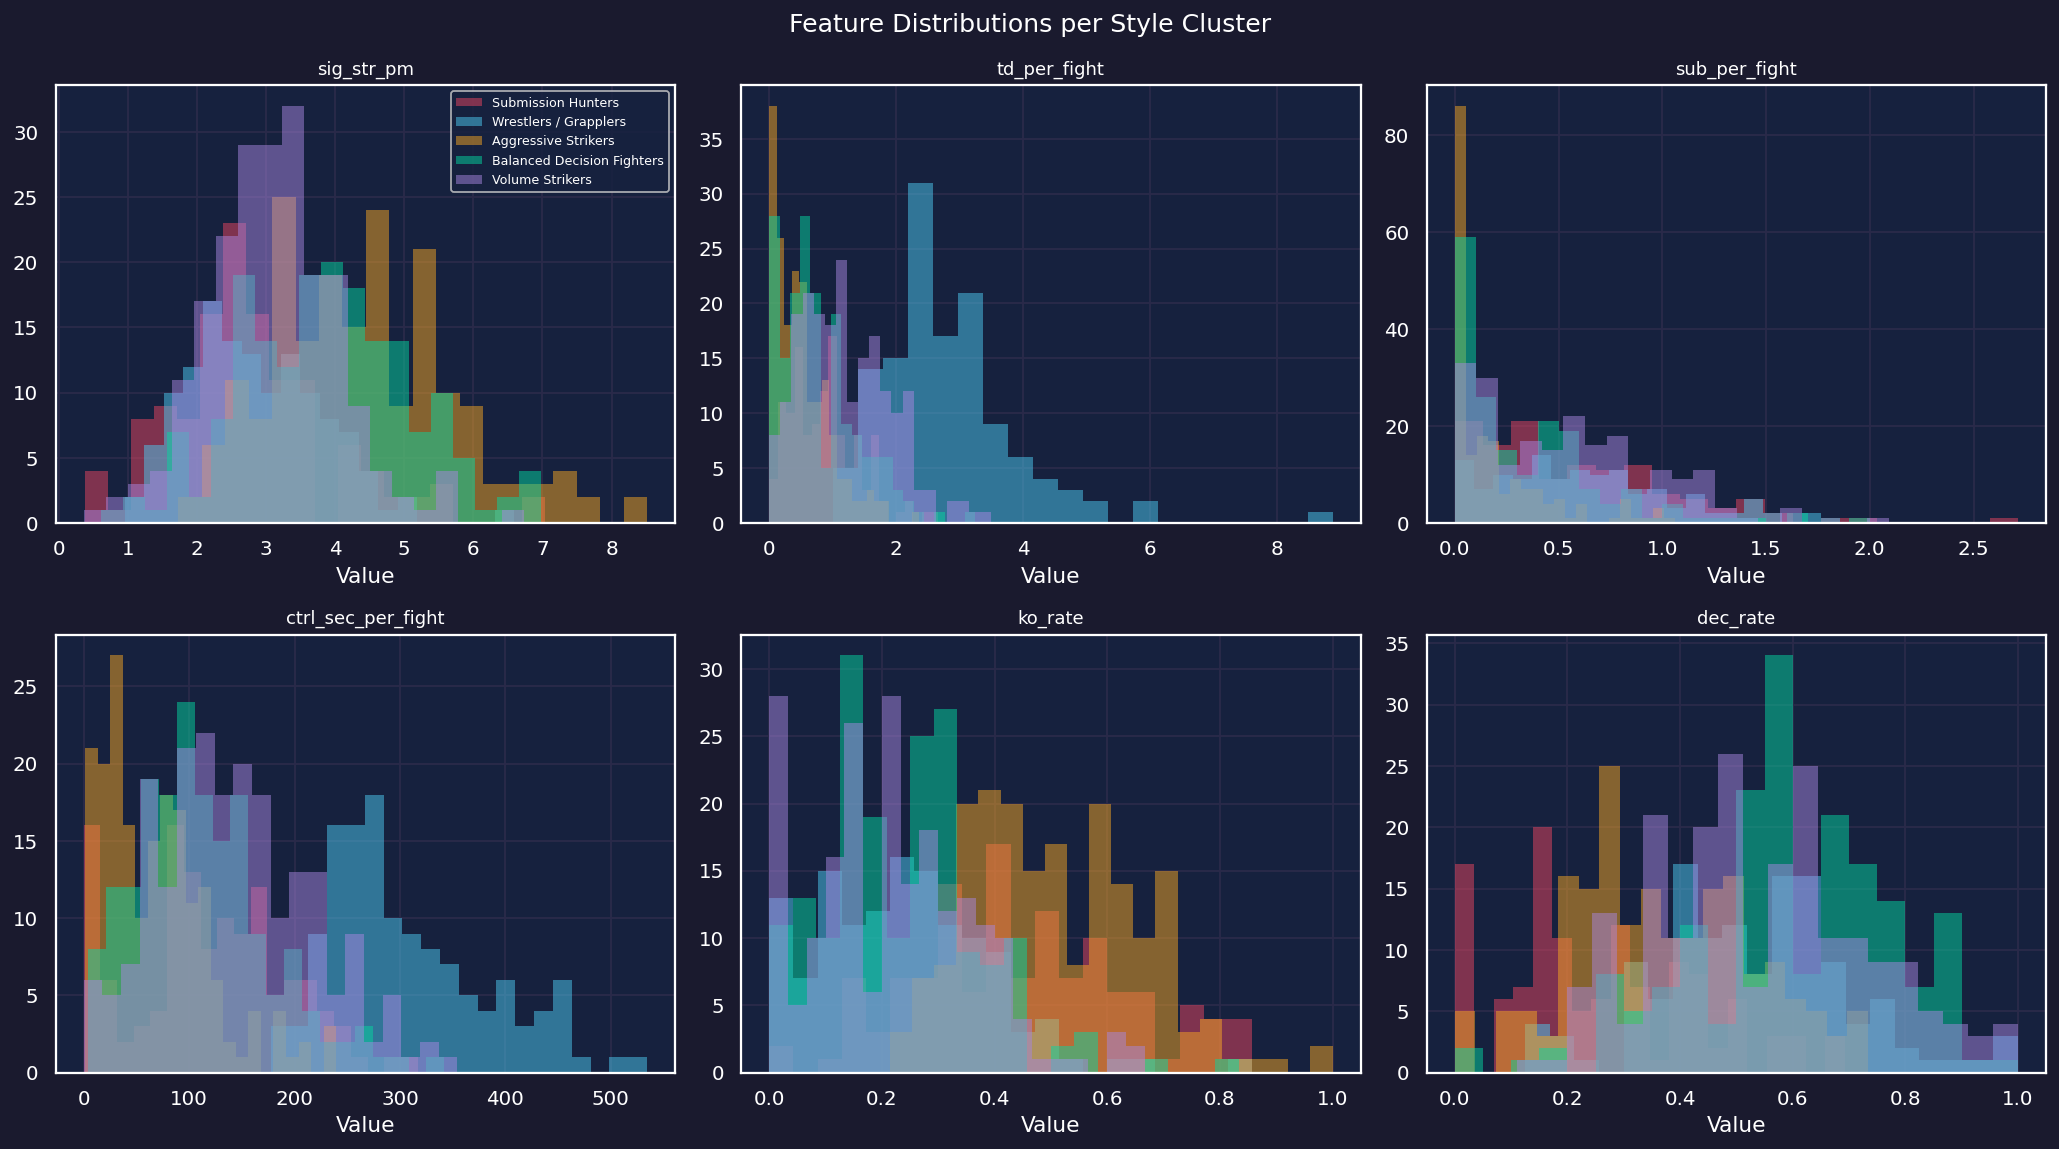

In [28]:
# ── Feature distributions per cluster ─────────────────────────
PLOT_FEATURES = ['sig_str_pm', 'td_per_fight', 'sub_per_fight',
                 'ctrl_sec_per_fight', 'ko_rate', 'dec_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Feature Distributions per Style Cluster', fontsize=14)

for ax, feat in zip(axes.flat, PLOT_FEATURES):
    for i, (cname, color) in enumerate(zip(CLUSTER_NAMES.values(), PALETTE)):
        data = features_raw[features_raw['style_label'] == cname][feat].dropna()
        ax.hist(data, bins=20, alpha=0.5, color=color,
                label=cname if feat == PLOT_FEATURES[0] else '', edgecolor='none')
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Value')

axes[0, 0].legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

#***Le Nouveau Dataset avec le nouveau Label***

In [29]:

OUTPUT_PATH = OUTPUT_DIR + 'fighter_clustered.csv'
features_raw.to_csv(OUTPUT_PATH, index=False)
print(f'✅ Saved to {OUTPUT_PATH}')
print(f'   Shape: {features_raw.shape}')
print(f'   Columns: {features_raw.columns.tolist()}')

✅ Saved to /content/drive/MyDrive/Colab Notebooks/UFC Project/data/processed/fighter_clustered.csv
   Shape: (835, 24)
   Columns: ['Fighter_Id', 'Fighter_Name', 'n_fights', 'weight_lbs', 'Stance', 'sig_str_pm', 'td_per_fight', 'sub_per_fight', 'kd_per_fight', 'ctrl_sec_per_fight', 'sig_str_accuracy', 'td_accuracy', 'head_ratio', 'body_ratio', 'leg_ratio', 'dist_ratio', 'clinch_ratio', 'ground_ratio', 'ko_rate', 'sub_rate', 'dec_rate', 'win_rate', 'cluster', 'style_label']


#***ML FLOW***

In [30]:
with mlflow.start_run(run_name=f'clustering_{FINAL_ALGO}_k{FINAL_K}_{FINAL_FEATURES}'):

    # Parameters — every decision we made
    mlflow.log_param('algorithm',        FINAL_ALGO)
    mlflow.log_param('k',                FINAL_K)
    mlflow.log_param('feature_set',      FINAL_FEATURES)
    mlflow.log_param('n_fighters',       len(features_raw))
    mlflow.log_param('n_features',       len(STYLE_FEATURES))
    mlflow.log_param('n_init',           20)
    mlflow.log_param('random_state',     42)

    # Metrics — how well it worked
    mlflow.log_metric('silhouette_score',       round(final_sil, 4))
    mlflow.log_metric('davies_bouldin_score',   round(final_db,  4))
    mlflow.log_metric('calinski_harabasz_score',round(calinski_harabasz_score(X_final, final_labels), 2))

    # Cluster sizes as metrics
    for c in range(FINAL_K):
        n = (final_labels == c).sum()
        mlflow.log_metric(f'cluster_{c}_size', n)

    # Artifact
    mlflow.log_artifact(OUTPUT_PATH)

    run_id = mlflow.active_run().info.run_id

print(f'✅ MLflow run logged  |  run_id: {run_id}')

✅ MLflow run logged  |  run_id: f954a8bcd76640d897dcfb0b9230867c
